In [16]:
"""Compare with Chen, 2010, Fig. 8.10"""
import sys
sys.path.append('../../../')
# %load_ext autoreload
# %autoreload 2

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import scipy.constants as sci_const
from mores.model.OneLayer import OneLayer
from mores.utils.postprocessing import Mueller2sigma0VH

plt.style.use(['science', 'ieee'])
# plt.style.use(['science', 'notebook'])
# plt.style.use(['science'])
plt.rcParams.update({'figure.dpi': '200'})

In [18]:
###########INPUT##########################
f = 17.0e9
epsr0 = 1.0
# epsr1 = 1.0
epsr2 = 5.0
delta1 = 0.1e-2
corr_len1 = 1.2e-2
delta2 = 0.5e-2
corr_len2 = 20e-2


# Dry snow Fig. 8.10 (a)
d = 0.45
tau0 = 0.30
a = 0.96
epsr1 = 1.6-1e-3j

# Wet snow Fig. 8.10 (b)
# d = 0.58
# tau0 = 2.5
# a = 0.17
# epsr1 = 1.7-0.005j

# 测试的分量
sca_mec = 'total' # sur, vol, sub, sub_vol, total
###########INPUT END##########################


# derived params
ke = tau0 / d
ks = ke * a
ka = ke - ks

Lambda = sci_const.speed_of_light / f
k = 2*np.pi / Lambda
surface_para = {'model': 'RoughSurface', 'delta': delta1, 'corr_len': corr_len1}
subsurface_para = {'model': 'RoughSurface', 'delta': delta2, 'corr_len': corr_len2}
inclusion_para = {'ks': ks, 'ka': ka}

mymodel = OneLayer(f=f, epsr0=epsr0, epsr1=epsr1, epsr2=epsr2, thickness=d, 
                 surface_para=surface_para, subsurface_para=subsurface_para, inclusion_para=inclusion_para)

################## Run model
theta_is = np.linspace(1., 80., 80)
Num = len(theta_is)
sigma0_VVs = np.zeros(Num)
sigma0_HHs = np.zeros(Num)
sigma0_HVs = np.zeros(Num)
sig_tmp = np.zeros(Num)
for i in range(Num):
    theta_i = theta_is[i]
    theta_s = theta_i
    geom = (theta_s, 180, theta_i, 0)
    Mue_sur = mymodel.Mue_surface(geom)
    Mue_vol = mymodel.Mue_volume(geom)
    Mue_sub = mymodel.Mue_subsurface(geom)
    Mue_sub_vol = mymodel.Mue_subsurface_volume(geom)
    Mue_total = Mue_sur + Mue_vol + Mue_sub + Mue_sub_vol
    if sca_mec == 'sur':
        Mue = Mue_sur
    elif sca_mec == 'vol':
        Mue = Mue_vol
    elif sca_mec == 'sub':
        Mue = Mue_sub
    elif sca_mec == 'sub_vol':
        Mue = Mue_sub_vol
    else:
        Mue = Mue_total
    
    # Mue = mymodel.Mue_total(geom)
    # Mue = np.diag([1]*4)
    sigma_VV, _, sigma_HV, sigma_HH = Mueller2sigma0VH(Mue)
    sigma0_VVs[i] = sigma_VV
    # sigma0_VVs[i] = 4*np.pi*Mue[0, 0]
    sigma0_HHs[i] = sigma_HH
    sigma0_HVs[i] = sigma_HV

sigma0_VV_dB = 10*np.log10(sigma0_VVs)
sigma0_HH_dB = 10*np.log10(sigma0_HHs)
# sigma0_HV_dB = 10*np.log10(sigma0_HVs)



e:\exps\lunar_scattering\lunar_regolith_scattering\mores\mores\test\compare_Chen\../../..\mores\core\VRT.py:53: UserWarning: The ssa (0.6748623651203948) is too high, the first-order iterative VRT solver may obtain inaccurate results.
  warnings.warn("The ssa ({}) is too high, the first-order iterative VRT solver may obtain inaccurate results.".format(ssa))


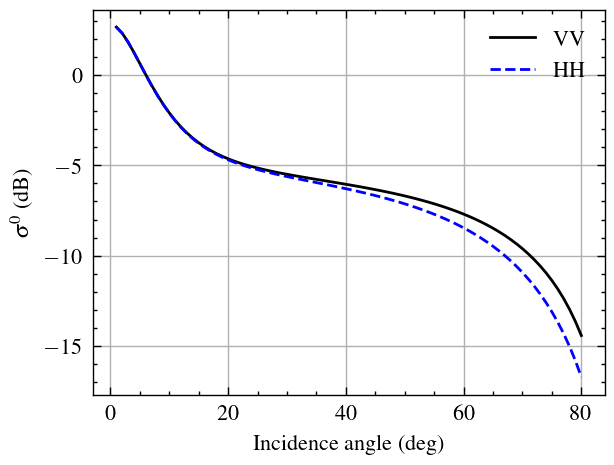

ks:0.6399999999999999, ka:0.026666666666666727, ke:0.6666666666666666, ssa:0.6748623651203948


In [19]:
###################### Plot
fig, ax = plt.subplots()
ax.plot(theta_is, sigma0_VV_dB, label='VV')
ax.plot(theta_is, sigma0_HH_dB, 'b', label='HH')
# plt.plot(theta_is, sig_tmp, 'g--', label='tmp')
# ax.set_xlim(0, 70)
# ax.set_ylim(-12, 3)
# ax.set_yticks(np.arange(-12, 3, 1))
ax.set_xlabel('Incidence angle (deg)')
ax.set_ylabel('$\sigma^0$ (dB)')
ax.legend()
ax.grid()
plt.savefig('../../../images/test1.png', dpi=300)
plt.show()
mymodel.layer.print_params()

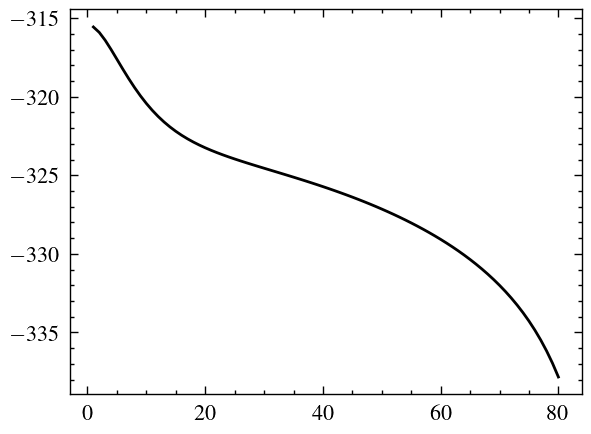

In [20]:
sigma0_HV_dB = 10*np.log10(sigma0_HVs)
fig, ax = plt.subplots()
ax.plot(theta_is, sigma0_HV_dB)
plt.show()